In [20]:
%matplotlib widget

In [21]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [22]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/UGC-3141_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/UGC-3141_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     371   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        52   (2094, 964)   float32   


In [23]:
image_cut = image[90:210, 0:1890]
image_error_cut = image_error[90:210, 0:1890]

In [24]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 50.74305555555554, 'wavelenght')

In [25]:
z = 0.03401
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

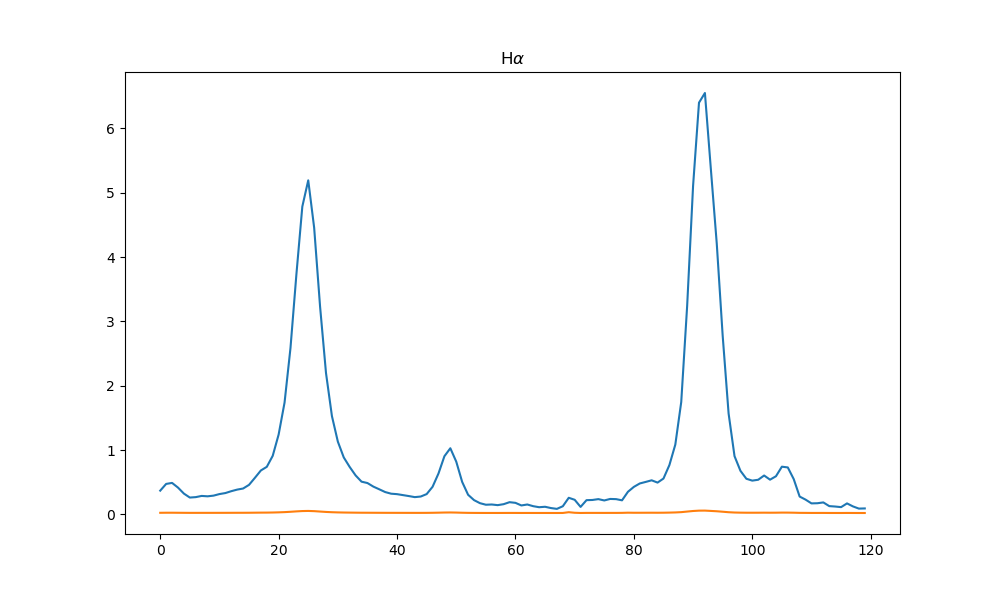

In [26]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

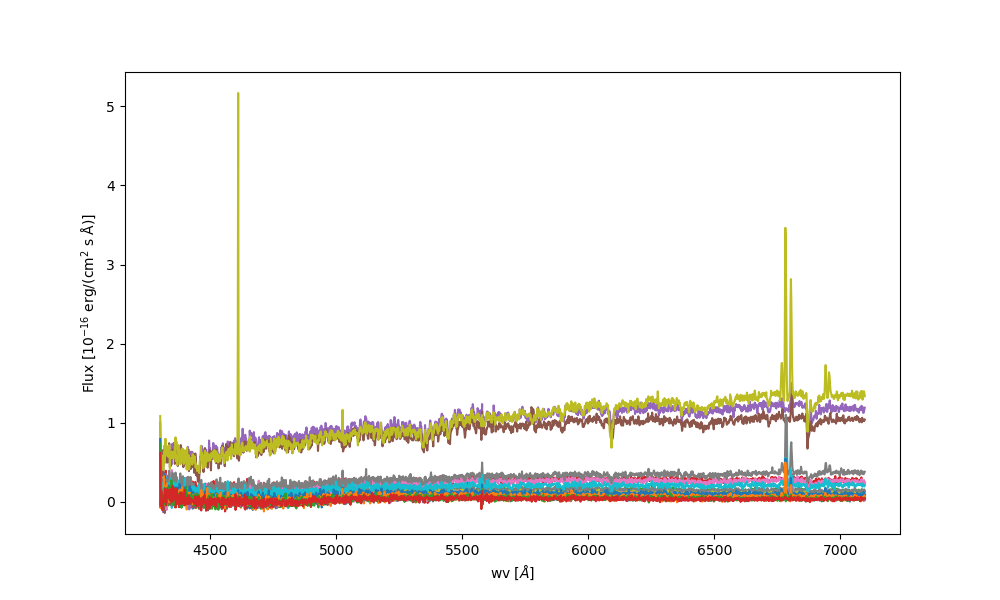

In [27]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('24ext', exist_ok=True)

spectra =  np.zeros((24, image_cut.shape[1]))
spectra_err = np.zeros((24, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(24):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('24ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [28]:
mask_continuum_1 = (wv > 4650)*(wv < 4950)
mask_continuum_2 = (wv > 5400)*(wv < 5700)
mask_continuum_3 = (wv > 6140)*(wv < 6440)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(20):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(20)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('24ext', 'SNR_24ext_continuum.csv')
df_path_snr = os.path.join('24ext', 'SNR_24ext_continuum.csv')
df_path_signal = os.path.join('24ext', 'Signal_24ext_continuum.csv')
df_path_noise = os.path.join('24ext', 'Noise_24ext_continuum.csv')
df_path_combined = os.path.join('24ext', 'Combined_24ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('24ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    1.027121    1.180789    2.183822    4.763965   12.935740   
Continuum_2    3.498386    4.841240    5.673617    9.270266   15.344189   
Continuum_3    4.666314    6.893747    7.820077   13.443810   25.553464   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  \
Continuum_1   12.229184    4.411512    2.212883    1.316579     1.060068   
Continuum_2   14.717466    9.776819    5.777952    4.680033     3.742470   
Continuum_3   28.058964   13.997926    8.533265    6.694886     4.530635   

             Spectrum_11  Spectrum_12  Spectrum_13  Spectrum_14  Spectrum_15  \
Continuum_1     0.037567    -0.091996    -0.095806     0.192196     0.194136   
Continuum_2     2.585099     2.560656     2.510734     2.593243     3.158954   
Continuum_3     3.030305     2.839405     2.916668     3.219394     3.488675   

             Spectrum_16  Spectrum_17  Spectrum_18  Spectr

## Redshift

In [29]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Spettro 1
Numero di righe trovate (regione centrale): 19
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 4327.379999999992   emission                 0
 4389.539999999974   emission                42
 5116.219999999759   emission               533
  5247.93999999972   emission               622
 5382.619999999681   emission               713
 5635.699999999606   emission               884
 6784.179999999267   emission              1660
 6804.899999999261   emission              1674
 6941.059999999221   emission              1766
 7050.579999999189   emission              1840
 4758.059999999865 absorption               291
 4835.019999999842 absorption               343
 4872.019999999831 absorption               368
 4920.859999999817 absorption               401
 5575.019999999624 absorption               843
 6167.019999999449 absorption              1243
  6400.85999999938 absorption  


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]

If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 6
Numero di righe trovate (regione centrale): 17
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
5773.339999999565   emission               977
5780.739999999563   emission               982
6769.379999999272   emission              1650
 6807.85999999926   emission              1676
4450.219999999956 absorption                83
4454.659999999954 absorption                86
5347.099999999691 absorption               689
5353.019999999689 absorption               693
5360.419999999687 absorption               698
 5384.09999999968 absorption               714
5444.779999999662 absorption               755
5450.699999999661 absorption               759
6094.499999999471 absorption              1194
6455.619999999364 absorption              1438
6868.539999999242 absorption              1717
6886.299999999237 absorption              1729
6896.659999999234 absorption              1736
Spe


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]

If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 8
Numero di righe trovate (regione centrale): 14
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
4382.139999999976   emission                37
4729.939999999873   emission               272
5265.699999999715   emission               634
5458.099999999658   emission               764
5577.979999999623   emission               845
5953.899999999512   emission              1099
7056.499999999187   emission              1844
4800.979999999852 absorption               320
4855.739999999836 absorption               357
5575.019999999624 absorption               843
 6400.85999999938 absorption              1401
6868.539999999242 absorption              1717
6872.979999999241 absorption              1720
6887.779999999237 absorption              1730
Spettro 9
Numero di righe trovate (regione centrale): 11
   line_center    line_type  line_center_index
     Angstrom                           

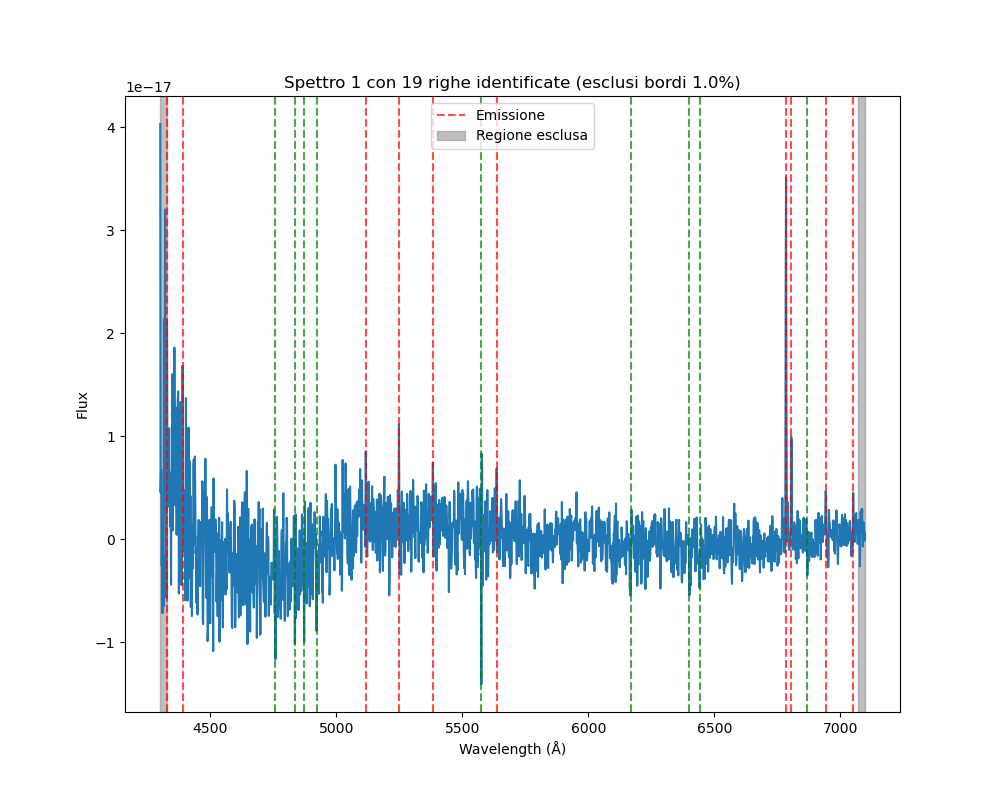

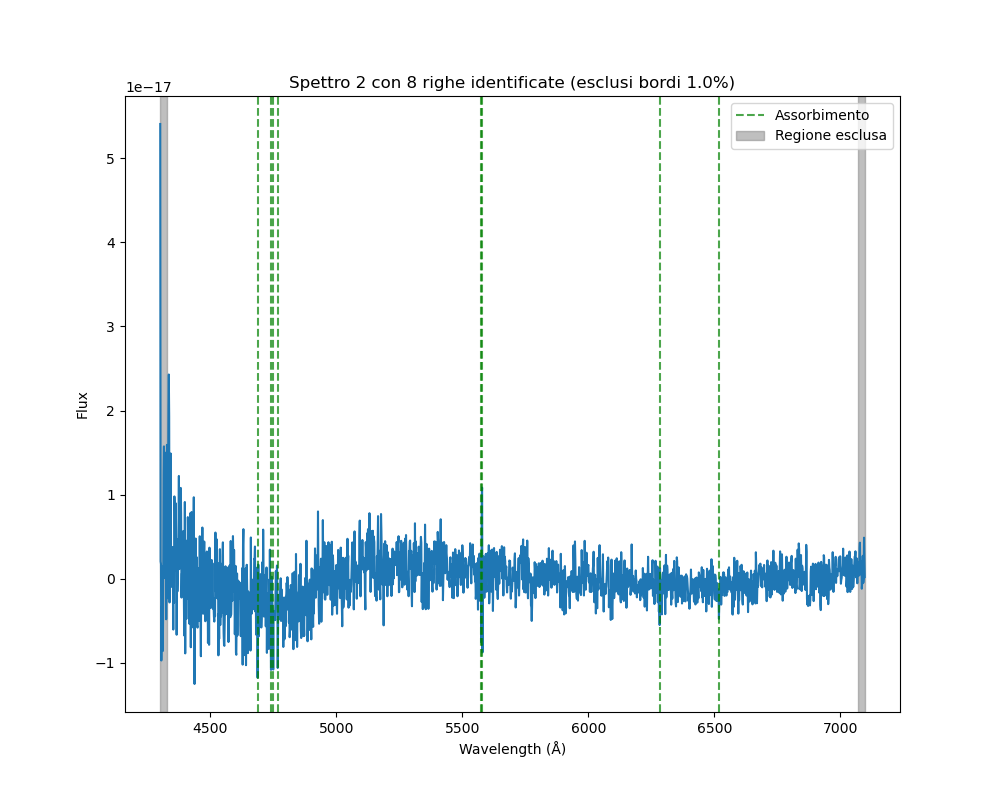

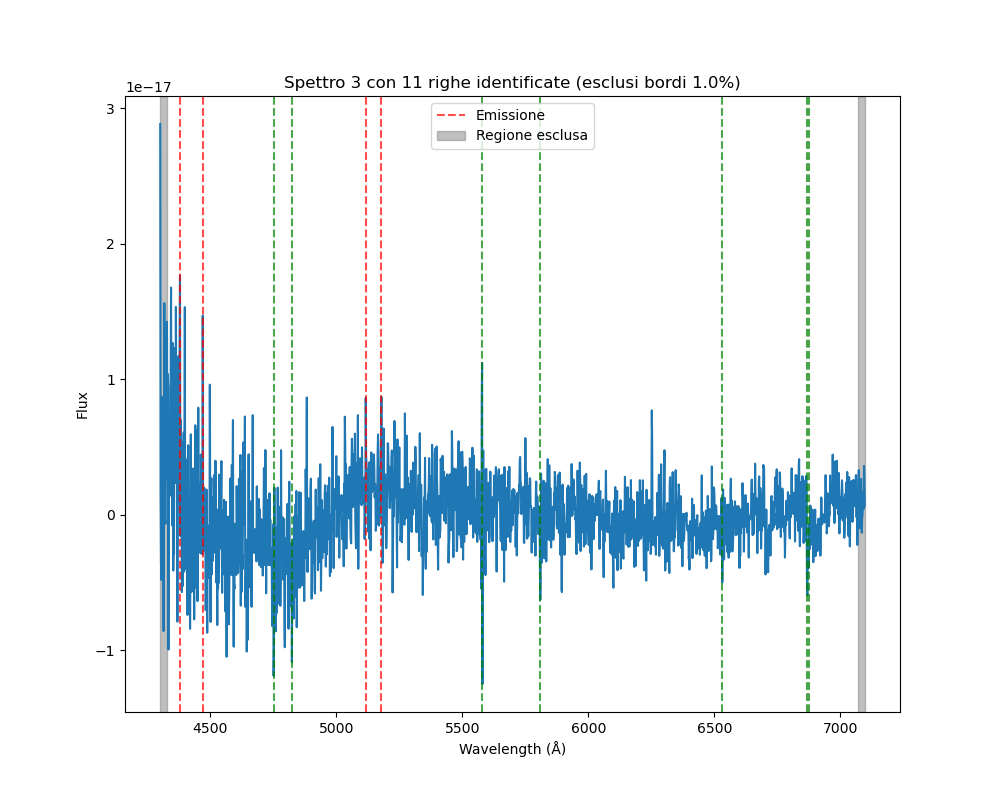

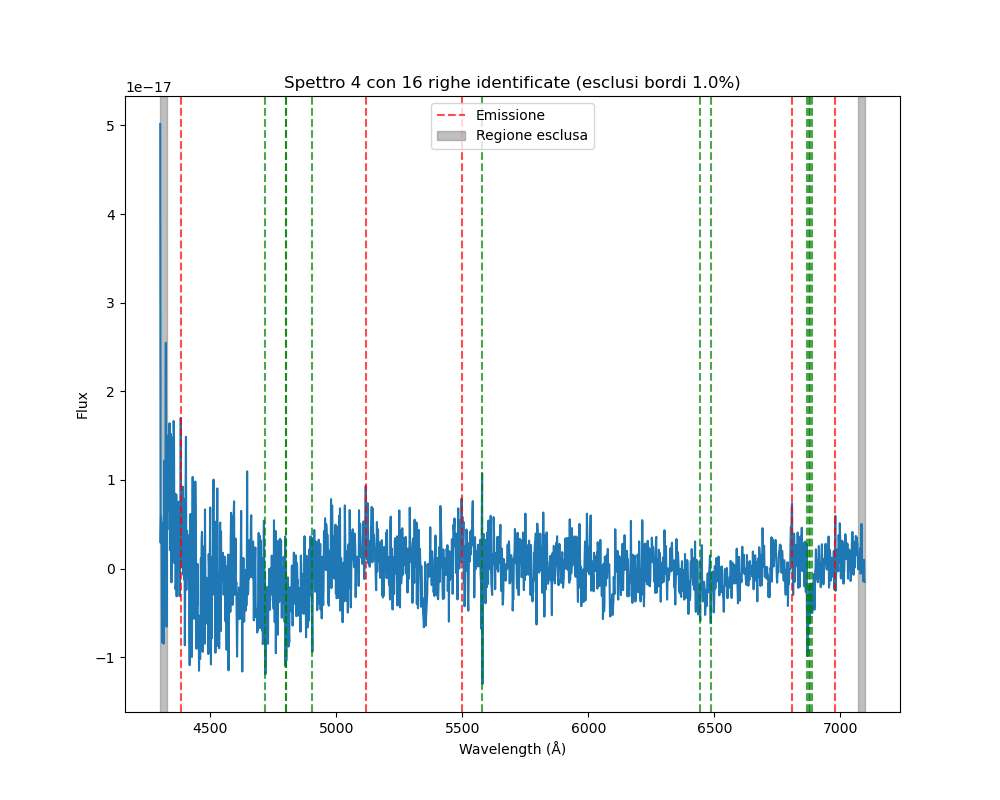

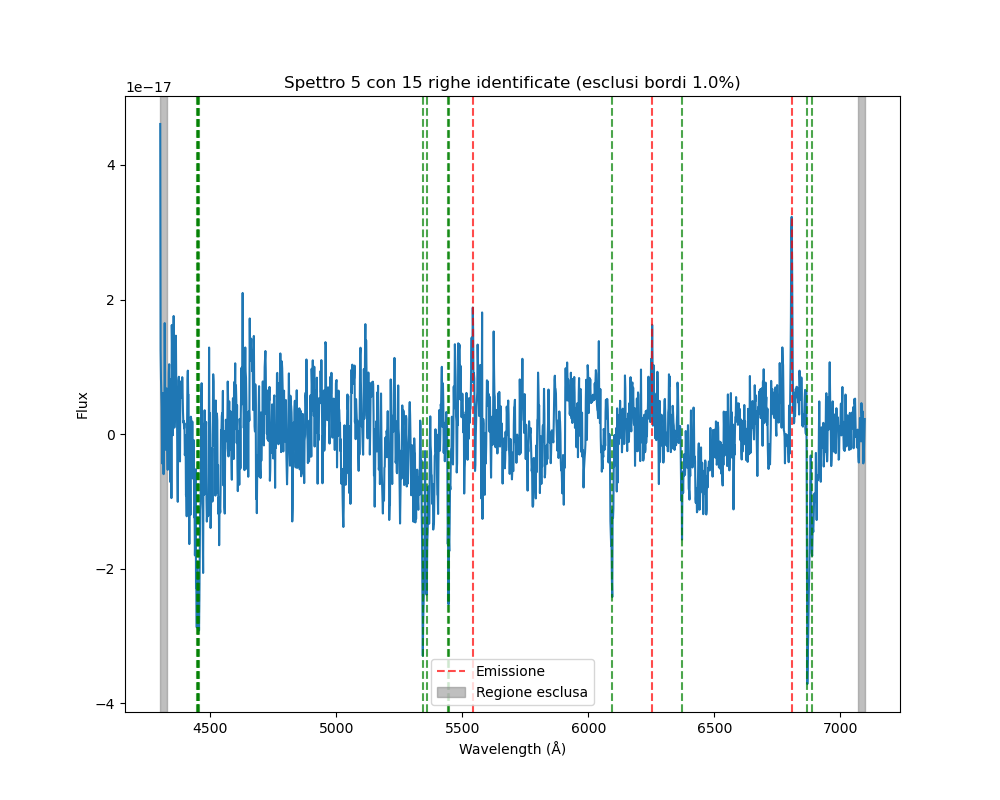

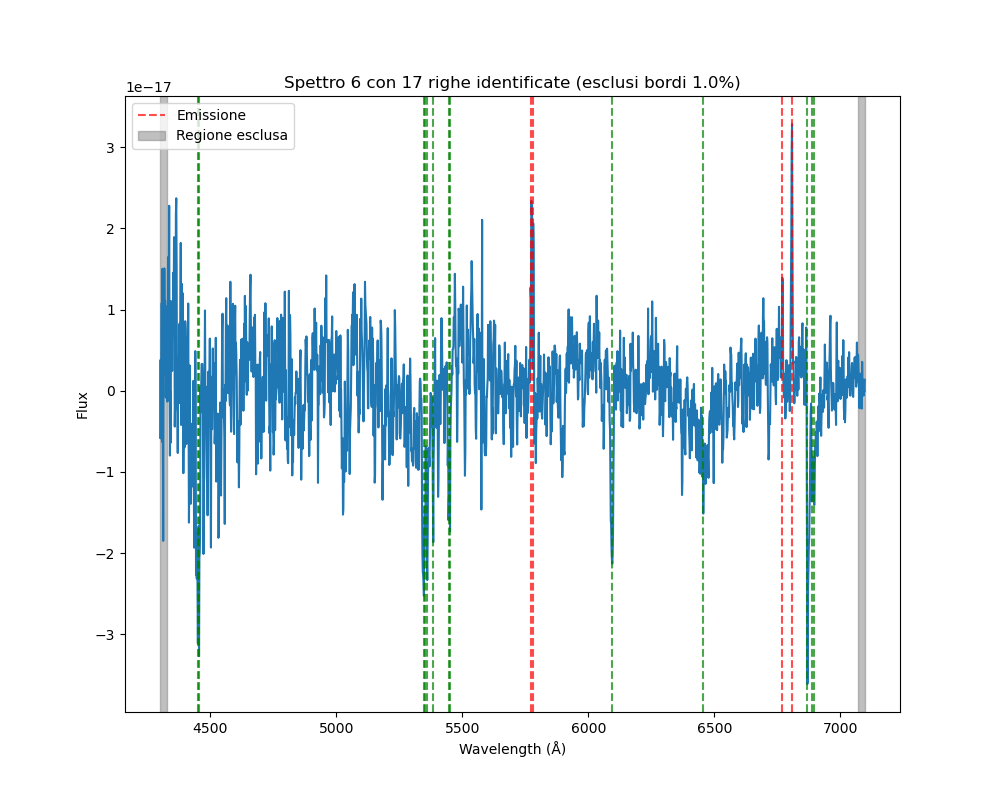

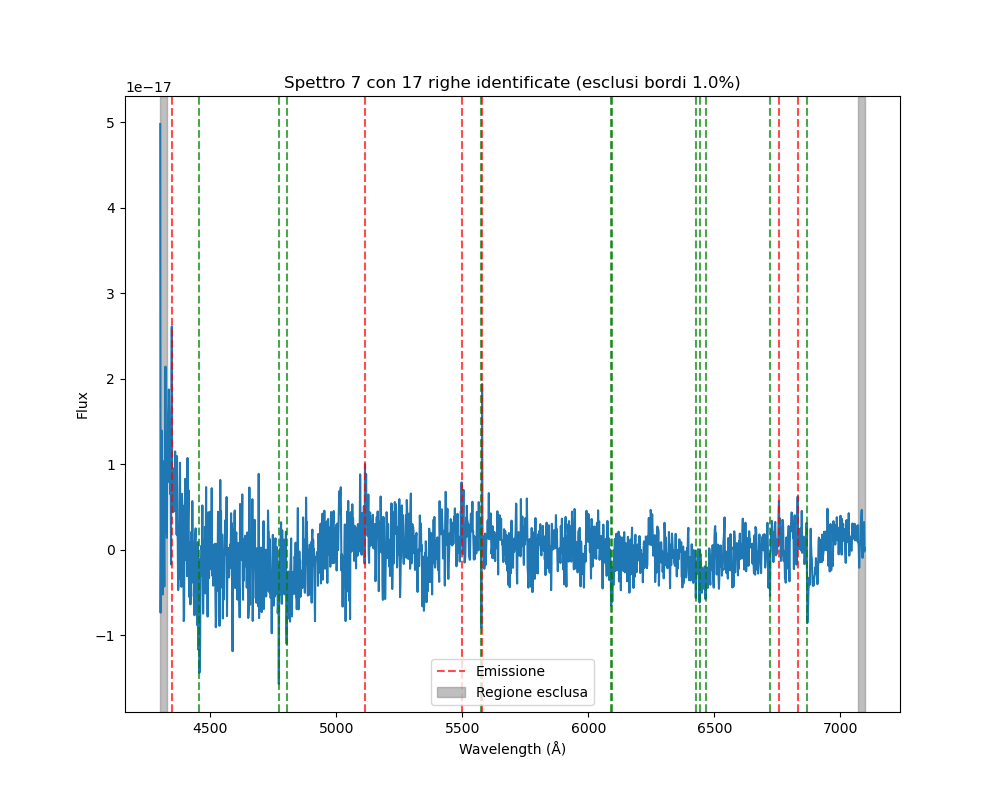

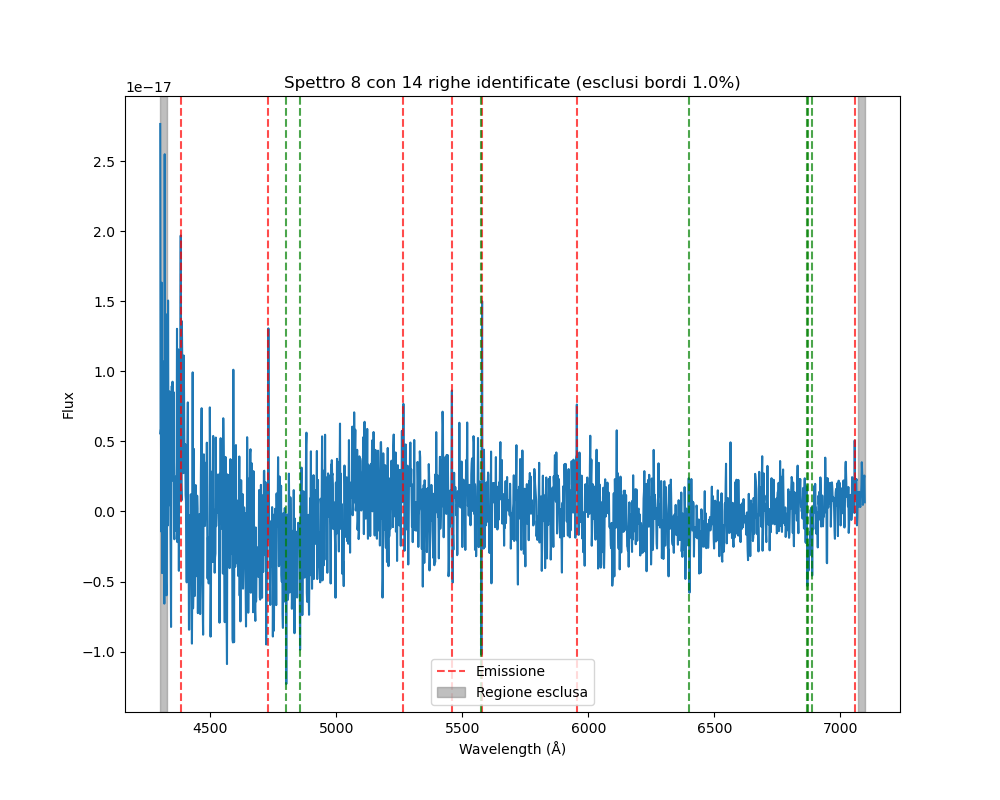

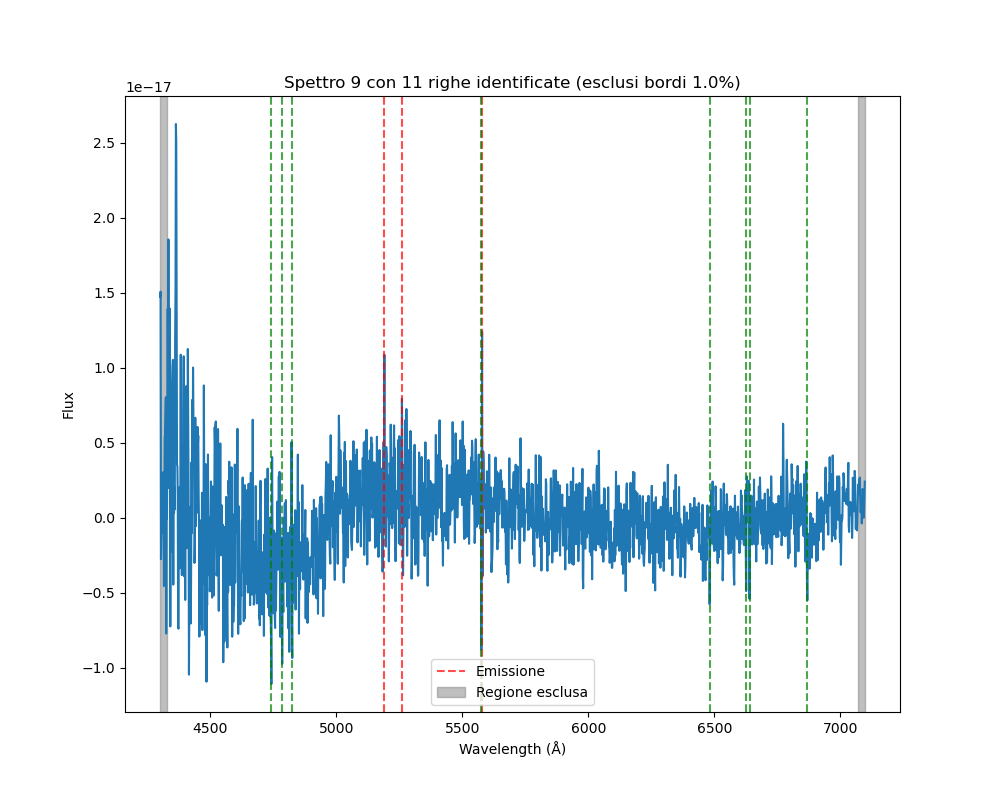

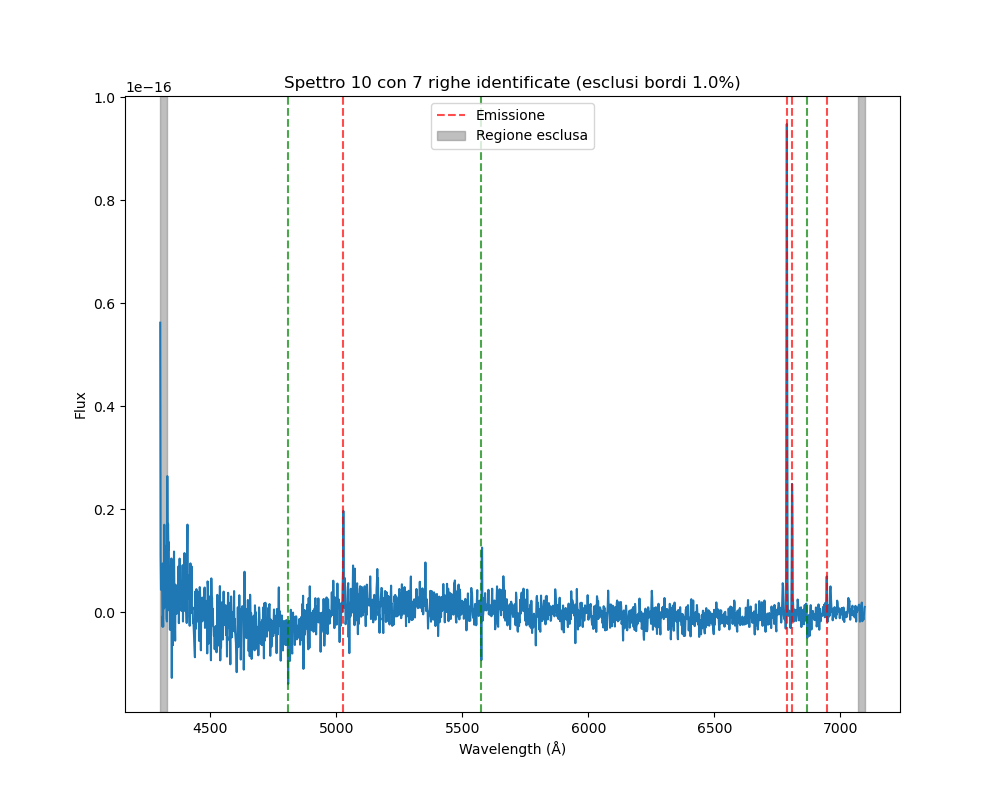

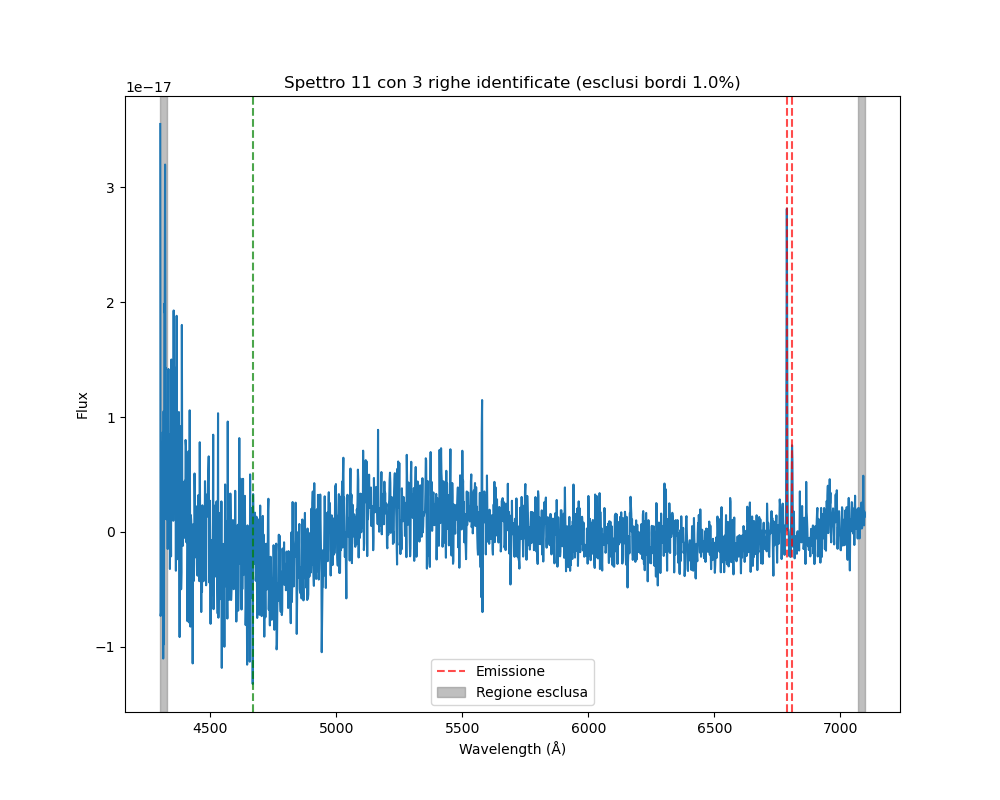

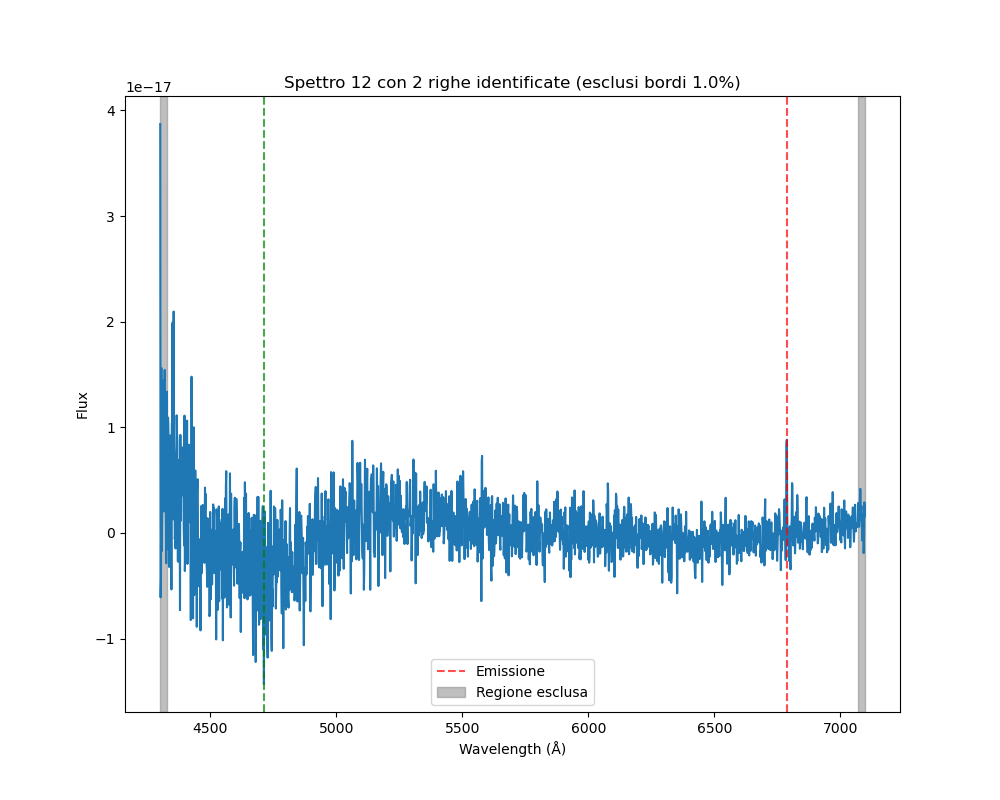

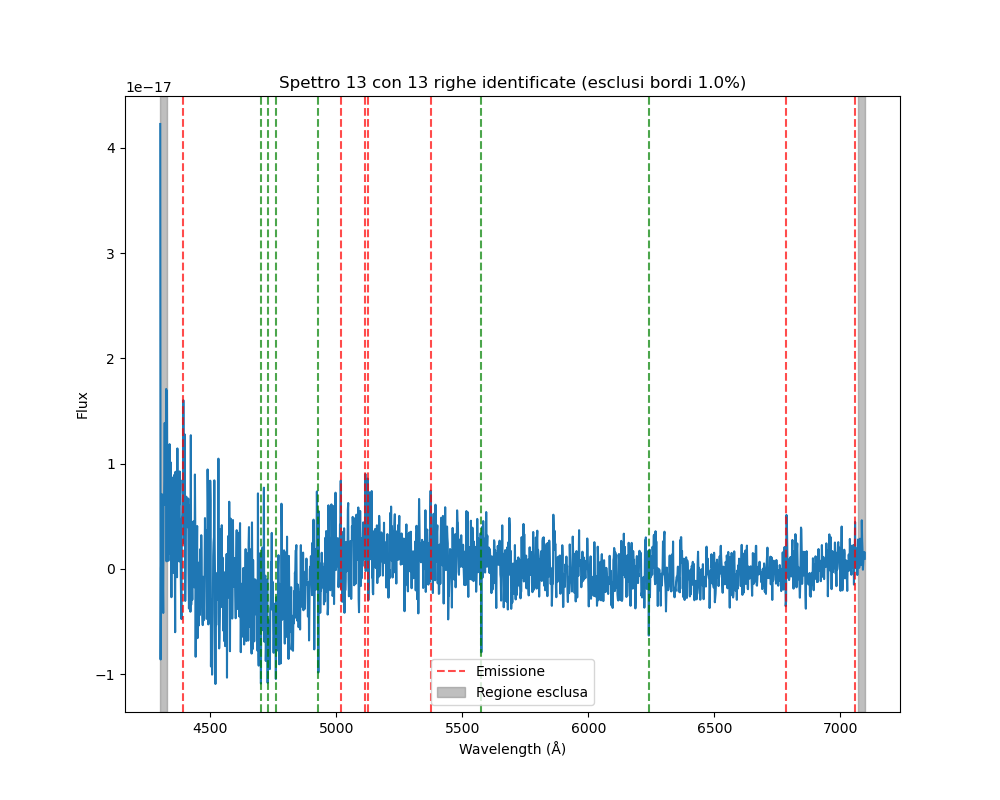

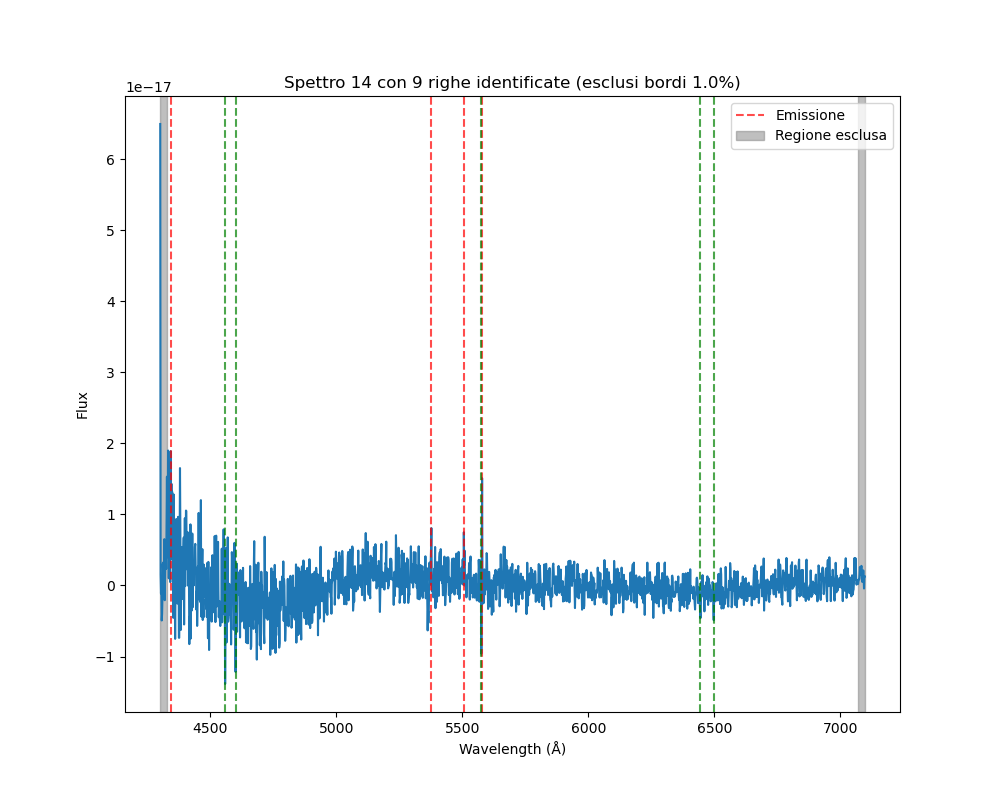

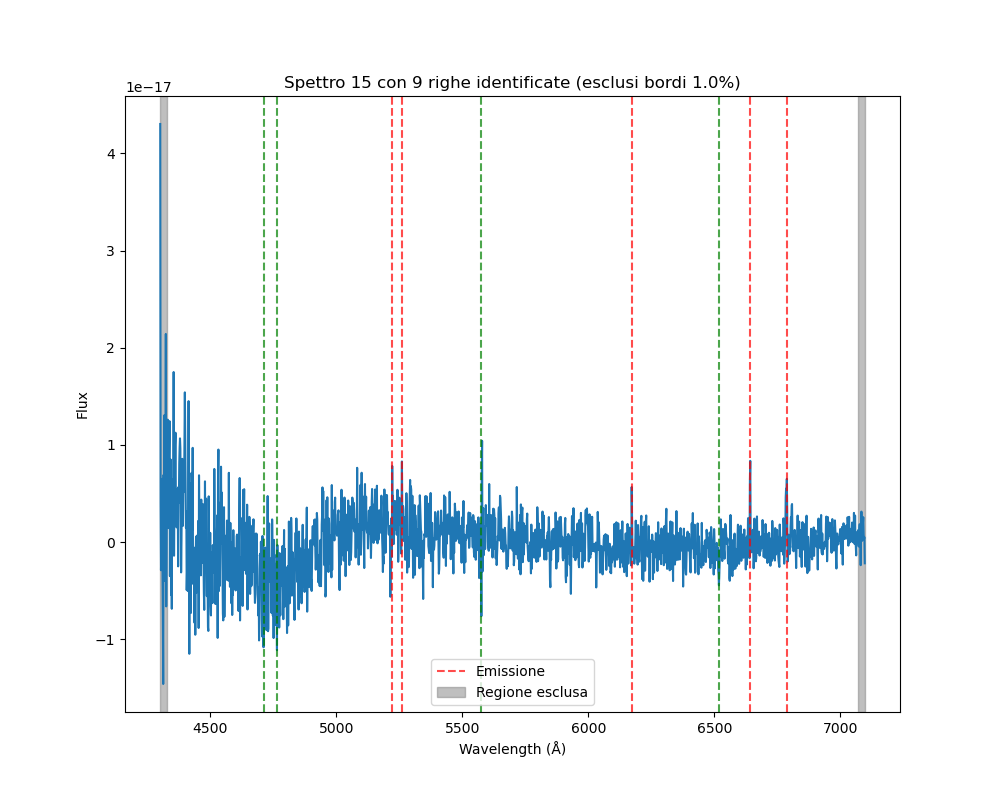

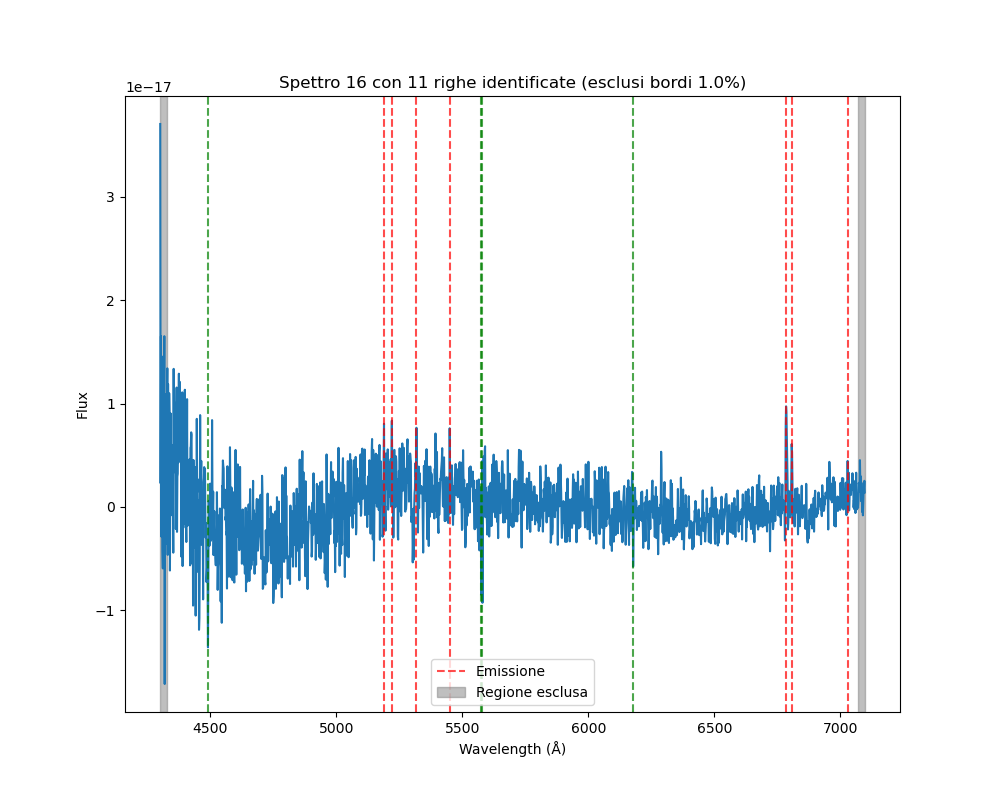

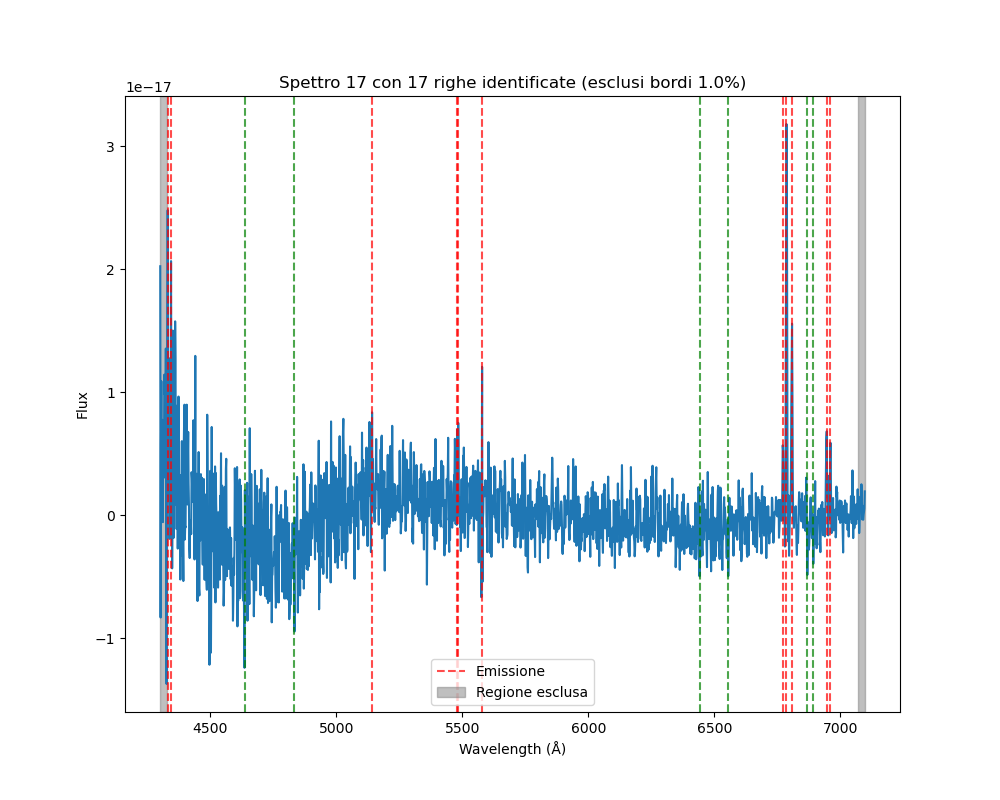

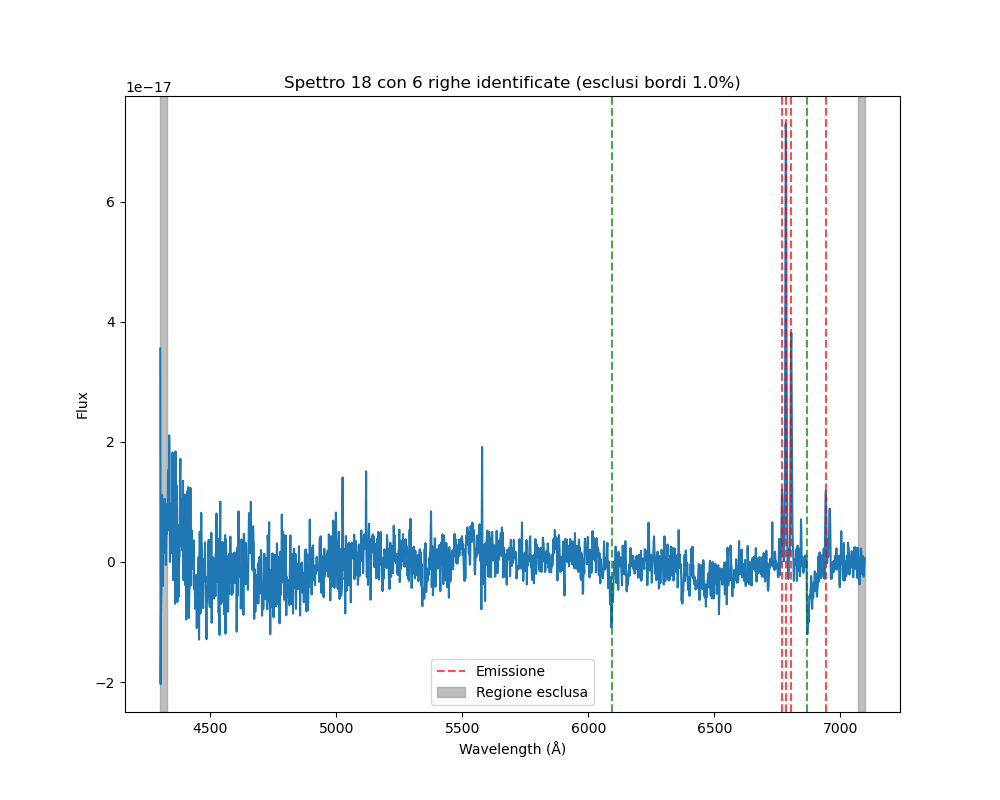

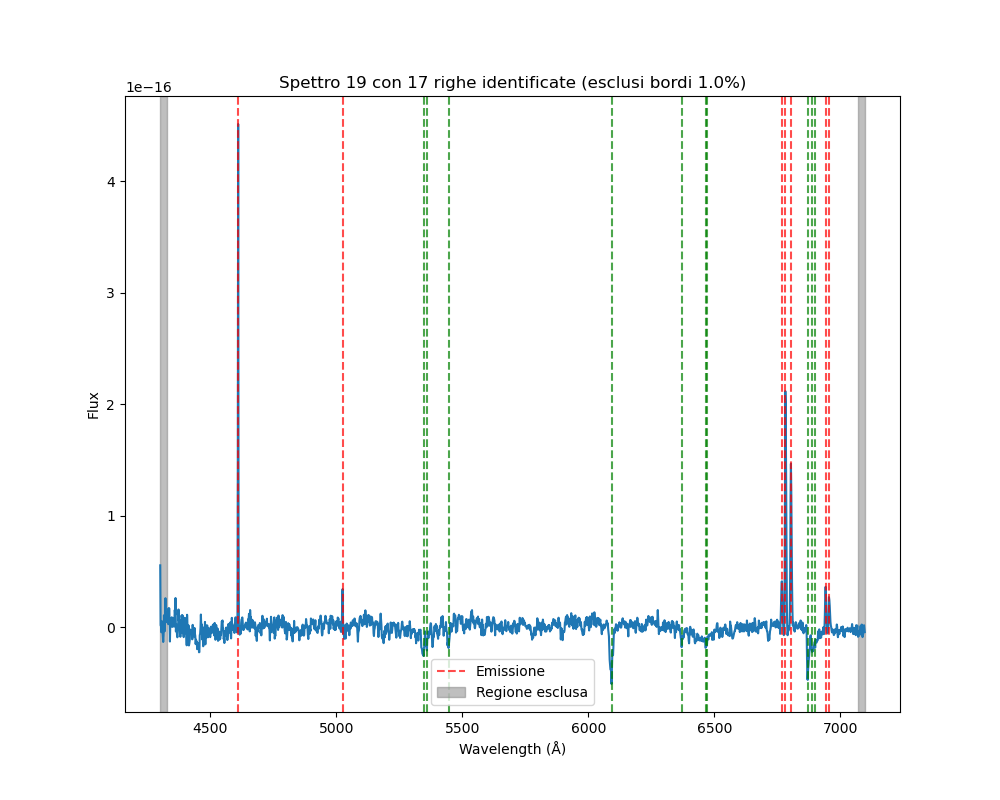

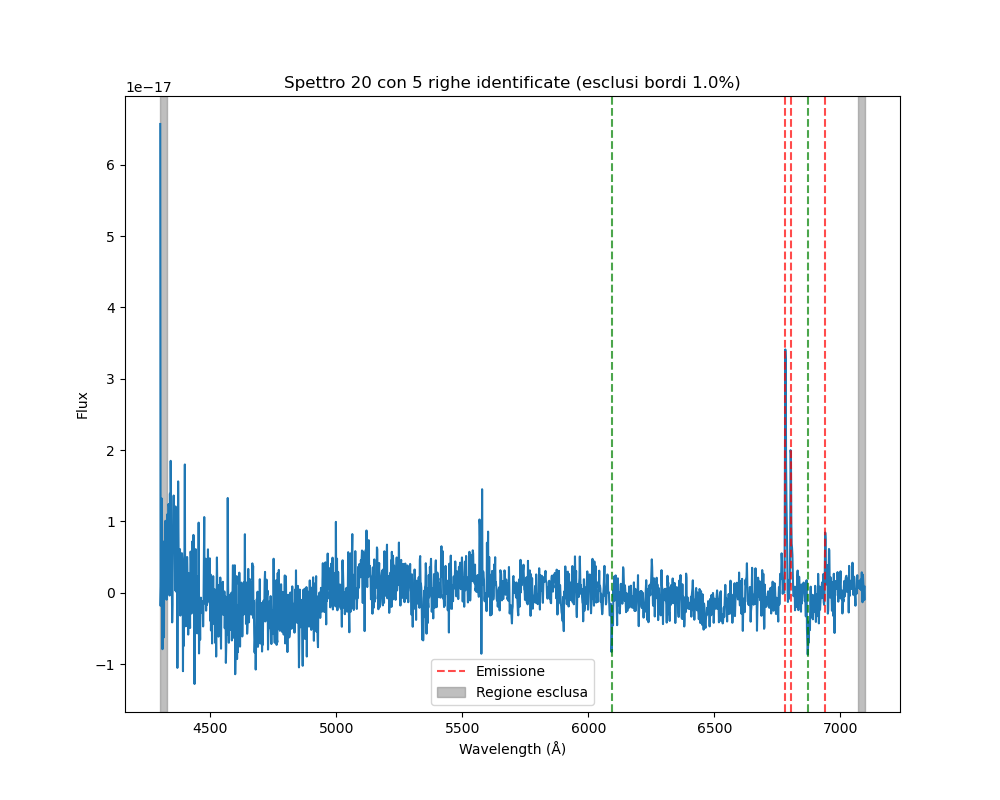

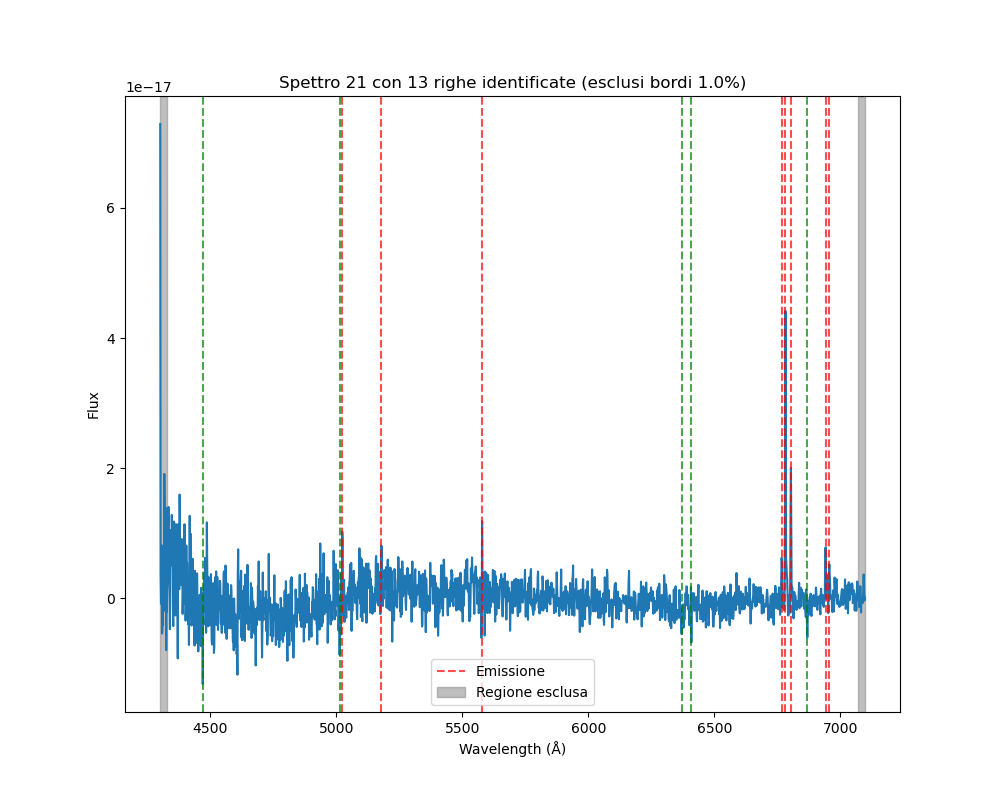

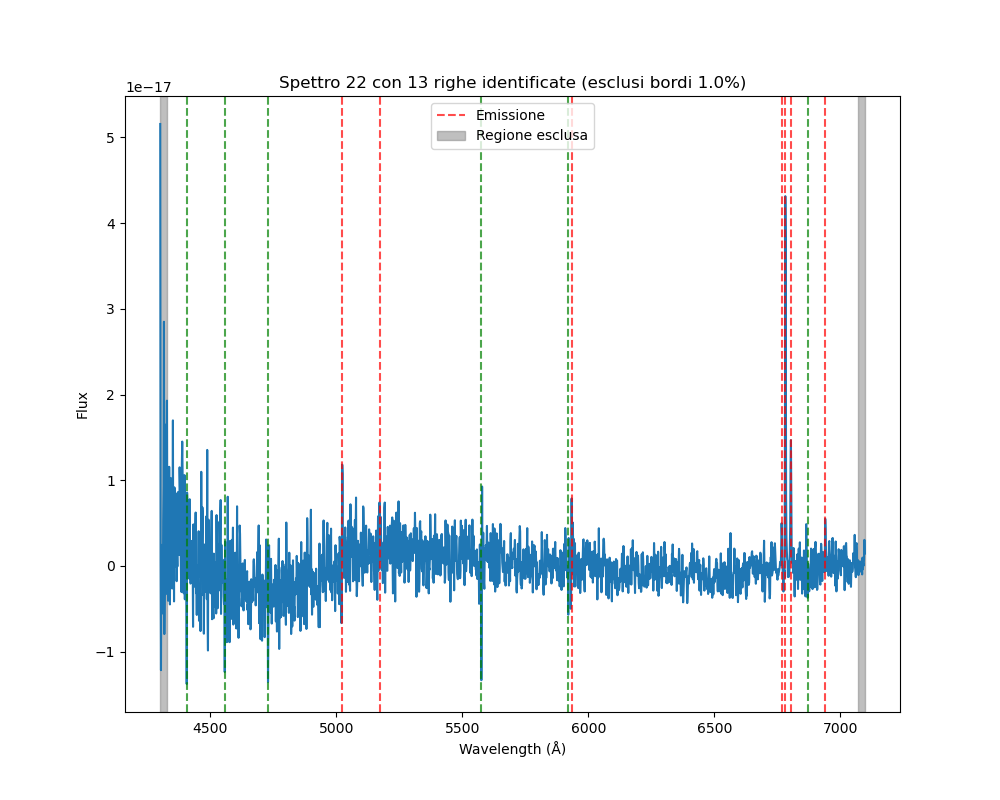

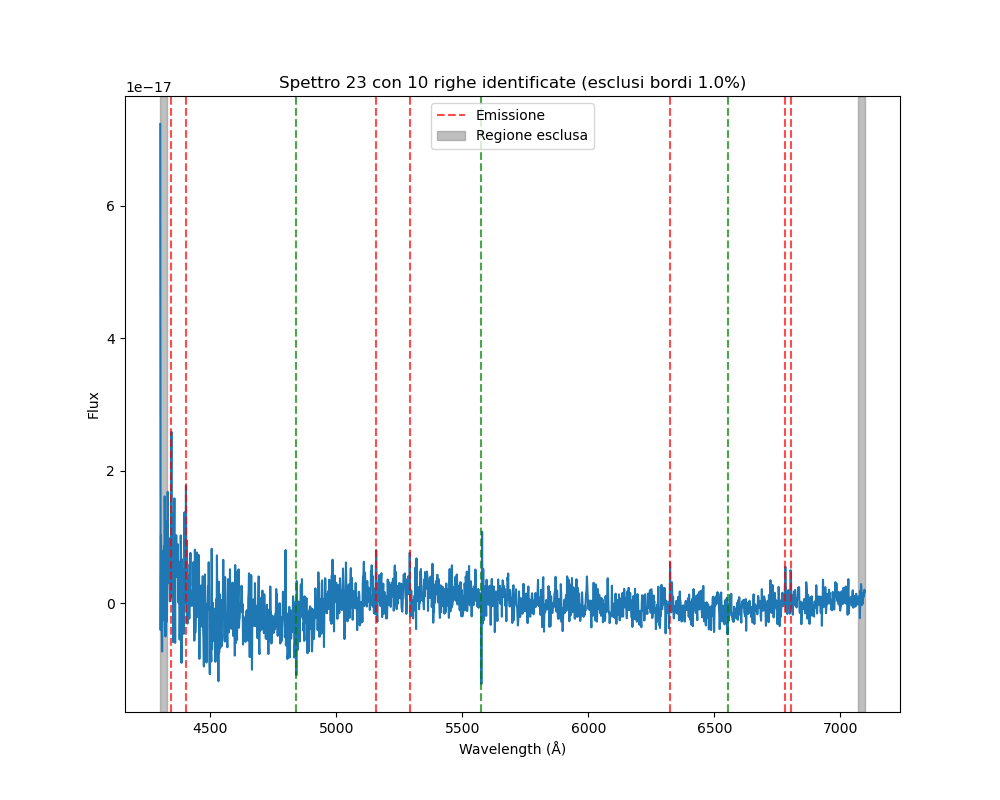

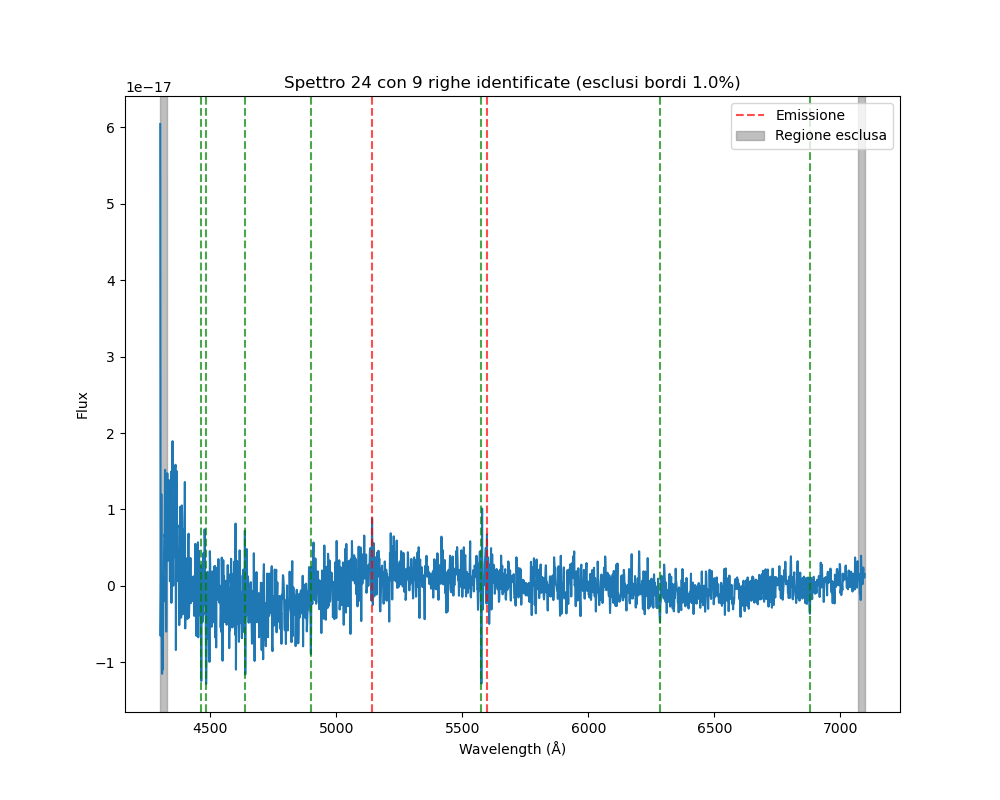

In [30]:
all_lines = []
noise_factor = [3, 3, 3, 3, 5, 5, 3, 3, 3, 4, 4, 4, 3, 3, 3, 3, 3, 5, 6, 4, 3, 3, 3, 3]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale
wv_central = wv[start_idx:end_idx]

for i in range(24):
    # Usa tutto lo spettro per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv * u.Angstrom,
        flux = spectra[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv * u.Angstrom)
    #f, ax = plt.subplots(figsize = (10,8))
    #ax.plot(wv * u.Angstrom, spectra[i]* 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    #ax.plot(wv * u.Angstrom, y_continuum_fitted)
    #ax.set_title("Continuum Fitting")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    #f2, ax2 = plt.subplots(figsize = (10,8))
    #ax2.plot(wv * u.Angstrom, flux_continuum_subtracted)
    
    #ax2.set_title("Spectrum without continuum")
    
    # Crea lo spettro solo per la regione centrale (senza bordi)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err[i][start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (regione centrale): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            # Trova l'indice più vicino alla posizione della riga nell'array wv_central
            line_idx = np.argmin(np.abs(wv_central - line_pos.value))
            # Ottieni l'indice corrispondente nel flux completo
            flux_idx = start_idx + line_idx
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[flux_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")

    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv[0], wv[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv[end_idx-1], wv[-1], alpha=0.5, color='gray', zorder=1)
    #ax3.axvline(x=wv[start_idx], color='gray', alpha=0.5, linestyle='-', linewidth=2, label='Regione esclusa')
    #ax3.axvline(x=wv[end_idx-1], color='gray', alpha=0.5, linestyle='-', linewidth=2)
    ax3.legend()
    
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [31]:
z

0.03401

In [32]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_1 = [l_HA, l_NII_2, l_SII_1]
lines_4 = [l_NII_2, l_SII_2]
lines_6 = [l_NII_1, l_NII_2]
lines_10 = [l_HB, l_HA, l_NII_2, l_SII_1]
lines_11 = [l_HA, l_NII_2]
lines_16 = [l_NII_1, l_HA,]
lines_17 = [l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_18 = [l_NII_1, l_HA, l_NII_2, l_SII_1]
lines_19 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_20 = [l_HA, l_NII_2, l_SII_1]
lines_21 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_22 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1]
lines_23 = [l_HA, l_NII_2]

lines_spectrum_1 = [6784.179999999267, 6804.899999999261, 6941.059999999221]
lines_spectrum_4 = [6807.85999999926, 6979.53999999921]
lines_spectrum_6 = [6769.379999999272, 6807.85999999926]
lines_spectrum_10 = all_lines[9]['line_center']
lines_spectrum_11 = all_lines[10]['line_center'] 
lines_spectrum_16 = [6784.179999999267, 6806.379999999261]
lines_spectrum_17 = [6770.859999999271, 6785.659999999267, 6807.85999999926, 6945.49999999922, 6960.299999999215]
lines_spectrum_18 = all_lines[17]['line_center']
lines_spectrum_19 = [5024.459999999786, 6767.899999999272, 6781.219999999268, 6803.419999999262, 6941.059999999221, 6954.379999999217]
lines_spectrum_20 = all_lines[19]['line_center']
lines_spectrum_21 = [5022.979999999787, 6766.4199999992725, 6781.219999999268, 6803.419999999262, 6941.059999999221, 6955.859999999217]
lines_spectrum_22 = [5022.979999999787, 6766.4199999992725, 6781.219999999268, 6803.419999999262, 6939.579999999221]
lines_spectrum_23 = [6781.219999999268, 6801.939999999262]

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std

z_1_mean, z_1_std = redshift_hand(lines_1, lines_spectrum_1)
z_4_mean, z_4_std = redshift_hand(lines_4, lines_spectrum_4)
z_6_mean, z_6_std = redshift_hand(lines_6, lines_spectrum_6) 

z_10_mean, z_10_std = redshift(lines_10, lines_spectrum_10) 
z_11_mean, z_11_std = redshift(lines_11, lines_spectrum_11) 

z_16_mean, z_16_std = redshift_hand(lines_16, lines_spectrum_16) 
z_17_mean, z_17_std = redshift_hand(lines_17, lines_spectrum_17) 
z_18_mean, z_18_std = redshift(lines_18, lines_spectrum_18) 
z_19_mean, z_19_std = redshift_hand(lines_19, lines_spectrum_19) 
z_20_mean, z_20_std = redshift(lines_20, lines_spectrum_20) 
z_21_mean, z_21_std = redshift_hand(lines_21, lines_spectrum_21) 
z_22_mean, z_22_std = redshift_hand(lines_22, lines_spectrum_22) 
z_23_mean, z_23_std = redshift_hand(lines_23, lines_spectrum_23) 

z = [z_1_mean, np.nan, np.nan, z_4_mean, np.nan, z_6_mean, np.nan, np.nan, np.nan, z_10_mean, z_11_mean, np.nan, np.nan, np.nan, np.nan, z_16_mean, z_17_mean, z_18_mean, z_19_mean, z_20_mean, z_21_mean, z_22_mean, z_23_mean, np.nan]
z_err =[z_1_std, np.nan, np.nan, z_4_std, np.nan, z_6_std, np.nan, np.nan, np.nan, z_10_std, z_11_std, np.nan, np.nan, np.nan, np.nan, z_16_std, z_17_std, z_18_std, z_19_std, z_20_std, z_21_std, z_22_std, z_23_std, np.nan]

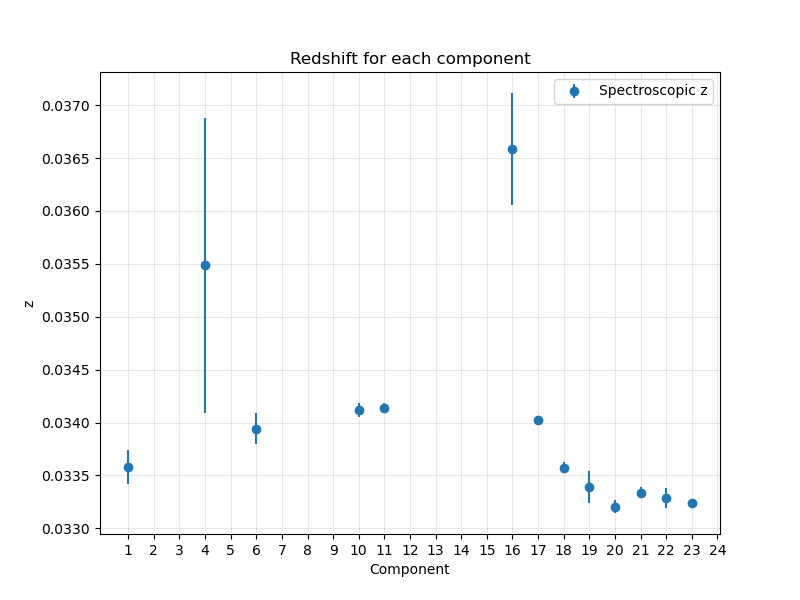

In [33]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 25, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
#plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift_grad', bbox_inches='tight')
plt.grid(alpha = 0.3)

red_table = np.column_stack((z, z_err))
np.savetxt('redshift_grad.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [34]:
z =  [z_1_mean, 0.03401, 0.03401, z_4_mean, 0.03401, z_6_mean, 0.03401, 0.03401, 0.03401, z_10_mean, z_11_mean, 0.03401, 0.03401, 0.03401, 0.03401, z_16_mean, z_17_mean, z_18_mean, z_19_mean, z_20_mean, z_21_mean, z_22_mean, z_23_mean, 0.03401]

In [35]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='24ext', num_spectra=24):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [36]:
SNR_HB = np.zeros(24)
signal_HB = np.zeros(24)
noise_HB = np.zeros(24)
SNR_SII_1 = np.zeros(24)
signal_SII_1 = np.zeros(24)
noise_SII_1 = np.zeros(24)
SNR_SII_2 = np.zeros(24)
signal_SII_2 = np.zeros(24)
noise_SII_2 = np.zeros(24)
SNR_NII_1 = np.zeros(24)
signal_NII_1 = np.zeros(24)
noise_NII_1 = np.zeros(24)
SNR_NII_2 = np.zeros(24)
signal_NII_2 = np.zeros(24)
noise_NII_2 = np.zeros(24)
SNR_HA = np.zeros(24)
signal_HA = np.zeros(24)
noise_HA = np.zeros(24)
SNR_OIII_1 = np.zeros(24)
signal_OIII_1 = np.zeros(24)
noise_OIII_1 = np.zeros(24)
SNR_OIII_2 = np.zeros(24)
signal_OIII_2 = np.zeros(24)
noise_OIII_2 = np.zeros(24)

for i in range(24):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                 SNR    Signal     Noise
Spettro_1   0.871479  0.069927  0.080239
Spettro_2  -1.720229 -0.125116  0.072732
Spettro_3  -2.202771 -0.195188  0.088610
Spettro_4   2.041830  0.201329  0.098602
Spettro_5  -3.964796 -0.482456  0.121685
Spettro_6  -3.350720 -0.489908  0.146210
Spettro_7  -1.822990 -0.289037  0.158551
Spettro_8  -4.653888 -0.354550  0.076184
Spettro_9  -1.323528 -0.116079  0.087704
Spettro_10  6.489650  0.616366  0.094977
Spettro_11  3.189751  0.255146  0.079989
Spettro_12  0.328512  0.028810  0.087697
Spettro_13 -0.368378 -0.040542  0.110055
Spettro_14  0.365283  0.020831  0.057026
Spettro_15 -0.161022 -0.016232  0.100804
Spettro_16 -0.289799 -0.032865  0.113405
Spettro_17  2.534122  0.288543  0.113863
Spettro_18  3.655545  0.461666  0.126292
Spettro_19  7.721030  1.215593  0.157439
Spettro_20  3.355691  0.134142  0.039974
Spettro_21  4.505509  0.442851  0.098291
Spettro_22  3.346438  0.289148  0.086405
Spettro_23  0.207967  0.020020  0.096265
Spettro_24 -0.65

'24ext\\SNR_OIII_2.csv'

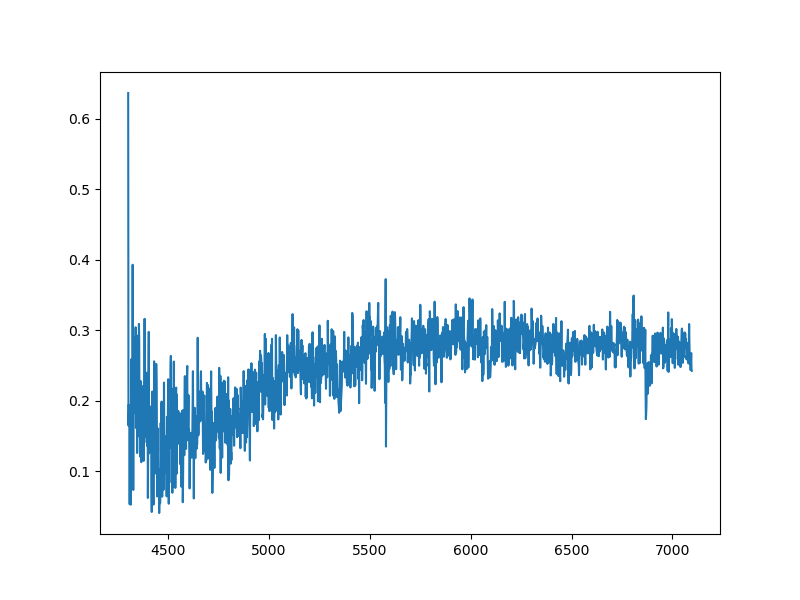

In [39]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[3])

In [38]:
l_OIII_2

5177.081268000001